In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/data_ecommerce_customer_churn.csv")

df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (3941, 11)

Columns:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']

Data types:
Tenure                      float64
WarehouseToHome             float64
NumberOfDeviceRegistered      int64
PreferedOrderCat             object
SatisfactionScore             int64
MaritalStatus                object
NumberOfAddress               int64
Complain                      int64
DaySinceLastOrder           float64
CashbackAmount              float64
Churn                         int64
dtype: object


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

Duplicate rows: 671


In [5]:
df = df.drop_duplicates()

df["Tenure"] = df["Tenure"].fillna(df["Tenure"].median())
df["WarehouseToHome"] = df["WarehouseToHome"].fillna(df["WarehouseToHome"].median())
df["DaySinceLastOrder"] = df["DaySinceLastOrder"].fillna(df["DaySinceLastOrder"].median())

print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape after cleaning: (3270, 11)

Missing values:
Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


Churn
0    2736
1     534
Name: count, dtype: int64


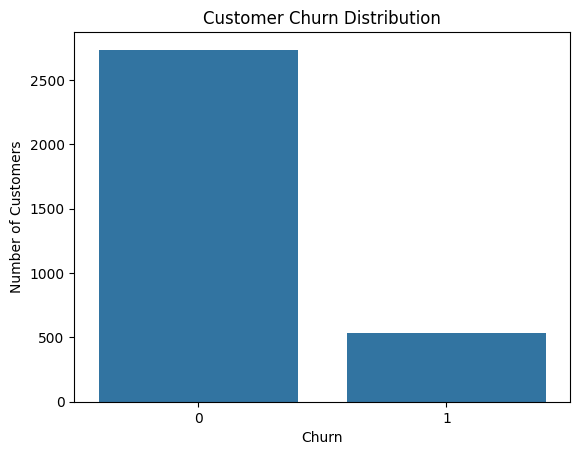

In [6]:
# Check the number of customers in each churn category
print(df["Churn"].value_counts())

# Show the churn distribution
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [7]:
# Calculate the percentage of customers in each churn category
churn_percent = df["Churn"].value_counts(normalize=True) * 100

print(churn_percent)


Churn
0    83.669725
1    16.330275
Name: proportion, dtype: float64


PreferedOrderCat
Mobile                27.074236
Mobile Phone          26.896552
Fashion               15.495868
Laptop & Accessory     9.810387
Others                 7.382550
Grocery                4.149378
Name: Churn, dtype: float64


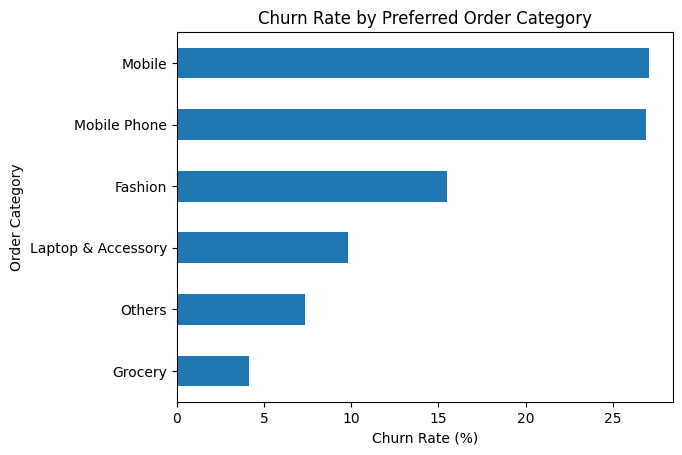

In [8]:
# Check churn rate for each order category
category_churn = df.groupby("PreferedOrderCat")["Churn"].mean() * 100

print(category_churn.sort_values(ascending=False))

# Plot churn by category
category_churn.sort_values().plot(kind="barh")

plt.title("Churn Rate by Preferred Order Category")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Order Category")
plt.show()

SatisfactionScore
1    11.173975
2    13.010204
3    17.489270
4    15.894040
5    22.834646
Name: Churn, dtype: float64


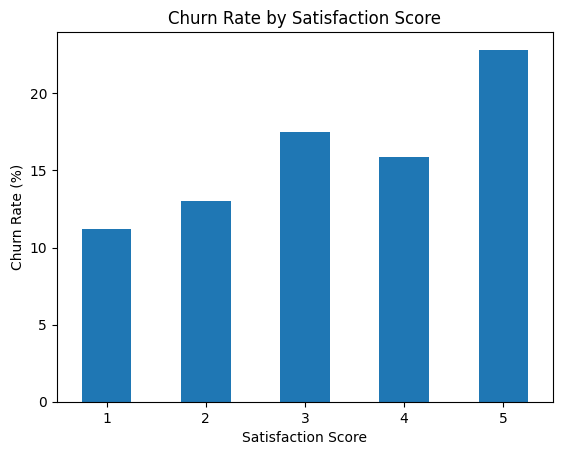

In [9]:
# Check churn rate for each satisfaction score
satisfaction_churn = df.groupby("SatisfactionScore")["Churn"].mean() * 100

print(satisfaction_churn)

# Plot satisfaction score against churn rate
satisfaction_churn.plot(kind="bar")

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Complain
0    10.259685
1    31.813246
Name: Churn, dtype: float64


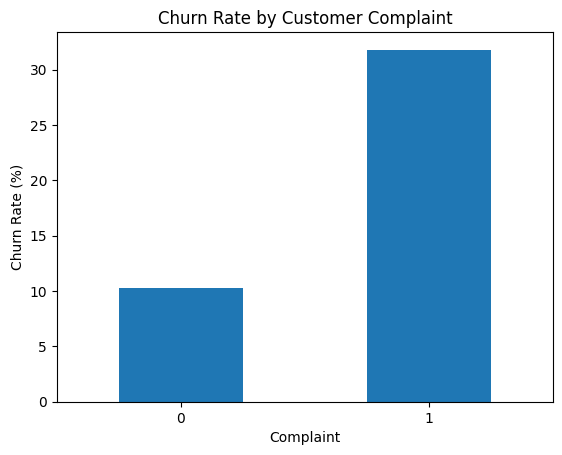

In [10]:
# Check churn rate for customers who complained
complain_churn = df.groupby("Complain")["Churn"].mean() * 100

print(complain_churn)

# Plot complaint vs churn
complain_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Complaint")
plt.xlabel("Complaint")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Tenure
0.0    54.255319
1.0    49.250000
2.0     8.737864
3.0    10.169492
4.0     9.230769
5.0     8.943089
6.0     2.586207
7.0     8.130081
8.0     6.622517
9.0    17.725753
Name: Churn, dtype: float64


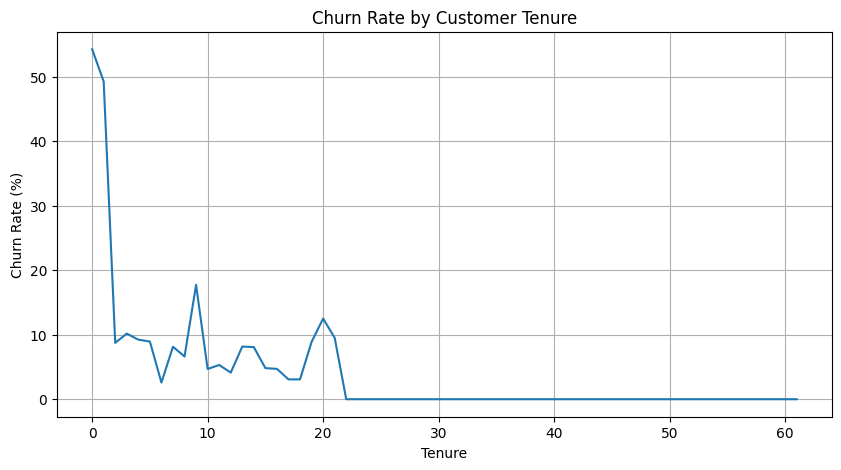

In [11]:
# Compare churn rate across customer tenure

tenure_churn = df.groupby("Tenure")["Churn"].mean() * 100

print(tenure_churn.head(10))

plt.figure(figsize=(10, 5))
tenure_churn.plot()
plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.grid()
plt.show()

DaySinceLastOrder
0.0    32.167832
1.0    27.808989
2.0    15.184382
3.0    14.921090
4.0    13.076923
5.0    13.740458
6.0    14.705882
7.0    15.019763
8.0    11.656442
9.0     8.670520
Name: Churn, dtype: float64


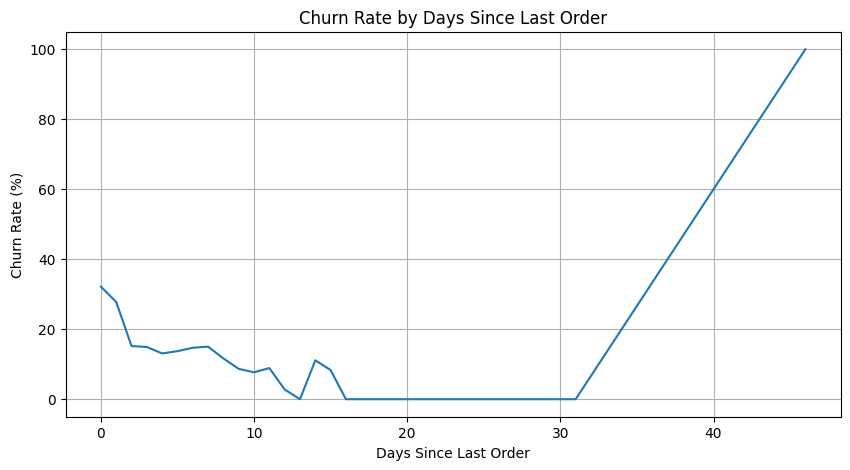

In [12]:
# Check churn rate based on days since last order
order_churn = df.groupby("DaySinceLastOrder")["Churn"].mean() * 100

print(order_churn.head(10))

plt.figure(figsize=(10, 5))
order_churn.plot()
plt.title("Churn Rate by Days Since Last Order")
plt.xlabel("Days Since Last Order")
plt.ylabel("Churn Rate (%)")
plt.grid()
plt.show()

In [14]:
# Separate input features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (3270, 15)
Target: (3270,)


In [15]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2616, 15)
Testing data: (654, 15)


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on test data
y_pred = model.predict(X_test)

# Check model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9097859327217125

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       547
           1       0.77      0.64      0.70       107

    accuracy                           0.91       654
   macro avg       0.85      0.80      0.82       654
weighted avg       0.91      0.91      0.91       654



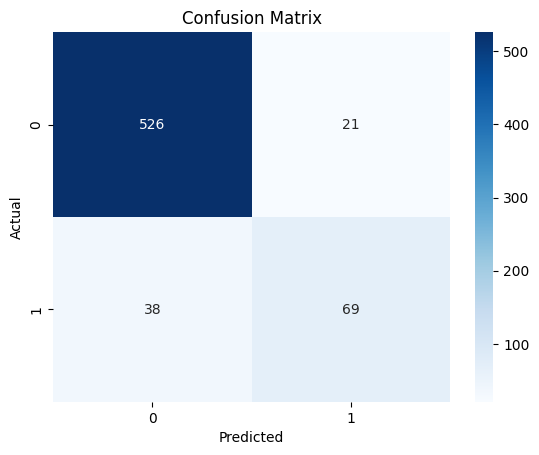

In [18]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Show confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Tenure                                 0.244371
CashbackAmount                         0.169538
WarehouseToHome                        0.115741
NumberOfAddress                        0.095716
DaySinceLastOrder                      0.084327
Complain                               0.066920
SatisfactionScore                      0.066235
NumberOfDeviceRegistered               0.053598
MaritalStatus_Single                   0.028954
MaritalStatus_Married                  0.018609
PreferedOrderCat_Laptop & Accessory    0.017949
PreferedOrderCat_Mobile Phone          0.017556
PreferedOrderCat_Mobile                0.012752
PreferedOrderCat_Grocery               0.004220
PreferedOrderCat_Others                0.003514
dtype: float64


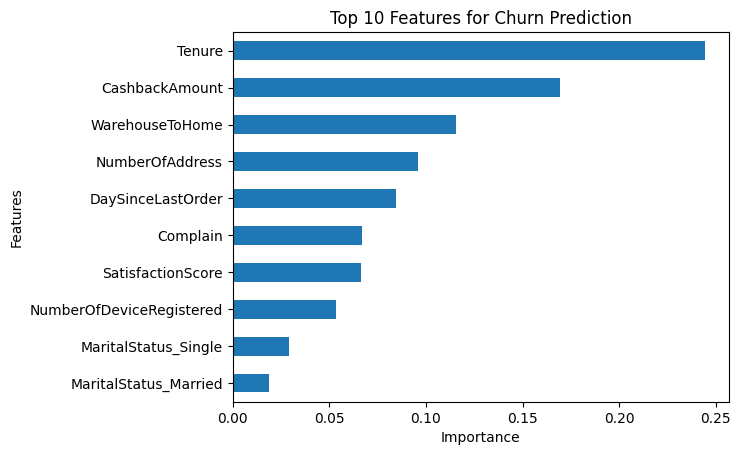

In [19]:
# Check which features are important for churn prediction
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

# Plot top important features
importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [20]:
# Predict churn for one sample customer
sample = X_test.iloc[[0]]

prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0][1]

print("Prediction:", "Churn" if prediction == 1 else "Not Churn")
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: Not Churn
Churn Probability: 1.0 %


In [22]:
import pickle
import os

# Create models folder if it does not exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
with open("../models/churn_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully.")

Model saved successfully.


In [23]:
import pickle

# Save the feature columns used by the model
with open("../models/feature_columns.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

print("Feature columns saved successfully.")


Feature columns saved successfully.
